In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay)

import os
import scipy
from scipy.stats import pearsonr

In [3]:
#Import the data

if not os.path.exists("../data/processed"):
    print("Processed Data Path does not exist. Expected in `../data/processed`. Run first data_exploration.ipynb")
    exit

#Load Training Data
X_train_cpg = pd.read_pickle('../data/processed/X_train_cpg.pkl')
y_train = pd.read_pickle('../data/processed/y_train.pkl')

#Load Validation Data
X_val_cpg = pd.read_pickle('../data/processed/X_val_cpg.pkl')
y_val = pd.read_pickle('../data/processed/y_val.pkl')

print('Data for training and validation set loaded successfully')

Data for training and validation set loaded successfully


In [4]:
import os
import sys

#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [5]:
#Apply stability selection for feature selection 

from src.functions import stability_selection

top200_allsubsamples = stability_selection(X_train_cpg, y_train)

KeyboardInterrupt: 

In [6]:
#Measure the frequency of each feature in the subsamples
from collections import Counter

counts = Counter(top200_allsubsamples)
frequency_series = pd.Series(counts)
frequency_norm = frequency_series/50 
frequency_perc = (frequency_series /50) *100 #number of total subsamples

os.makedirs('../figures/Task3_Figures', exist_ok=True)

In [ ]:
#Visualize the frequency percentage for the selected features

plt.figure(figsize=(12,40))
sns.barplot(x=frequency_perc.values, y=frequency_perc.index, palette='viridis')
plt.title("Frequency of top 200 CpG features among the 50 subsamples")
plt.ylabel("CpG Site", fontsize=1)
plt.xlabel("Frequency (%)")
plt.savefig('../figures/Task3_Figures/Top200_CpG_Frequency_among_subsamples.png', dpi=300, bbox_inches='tight')
plt.show()


The number of stable features selected is: 186


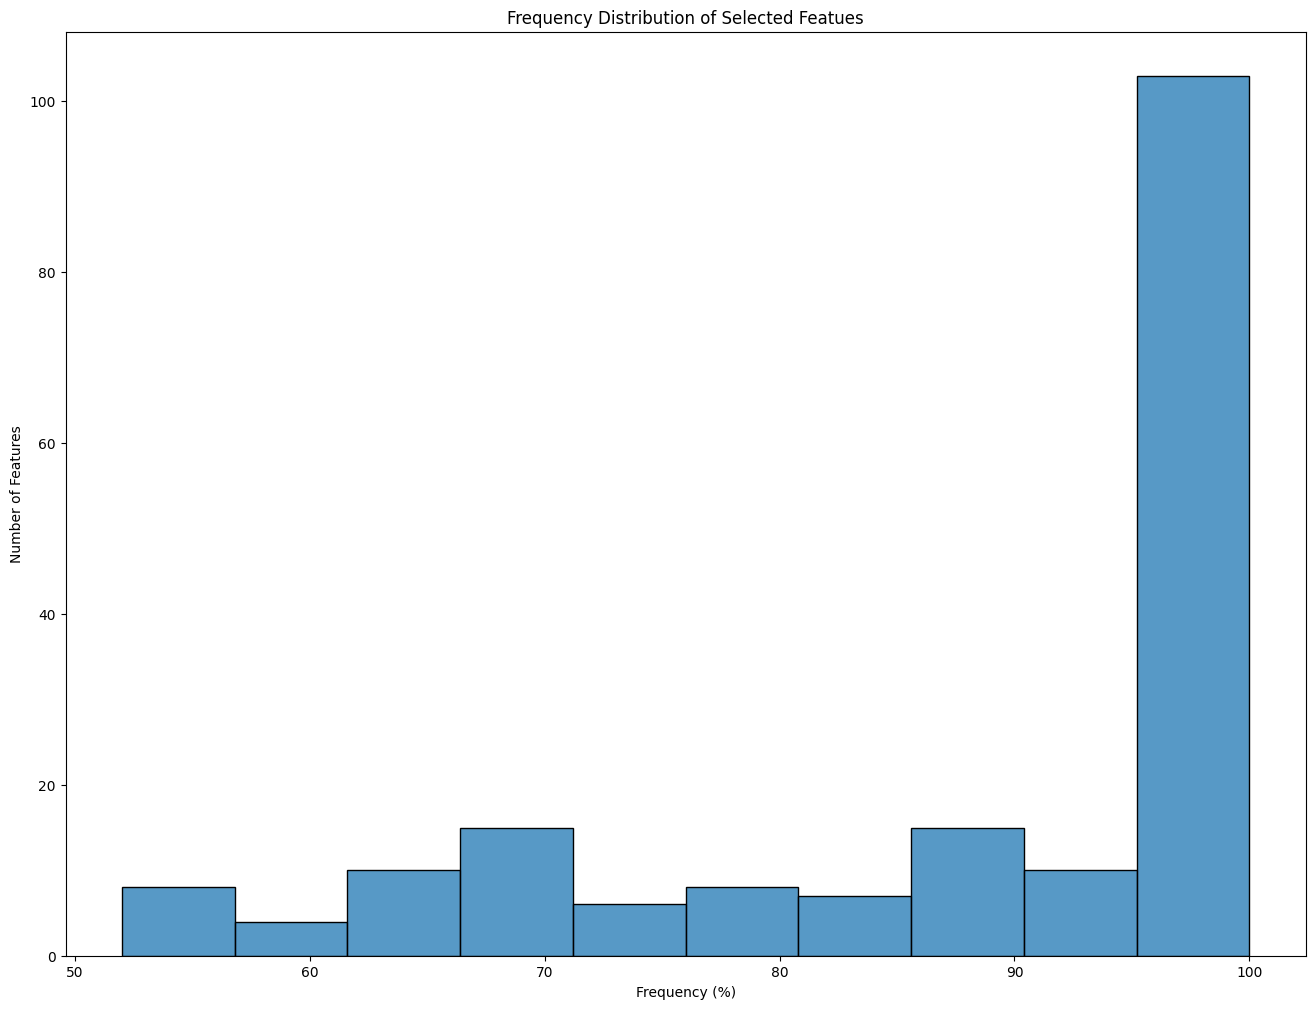

In [7]:
#Filter the results from running stability selection based on frequency - a feature is stable if it appears in more than half of the 50 resamples

stable_feature_freq = frequency_perc[frequency_perc > 50].sort_values(ascending=False)
print(f"The number of stable features selected is: {len(stable_feature_freq)}")

#Generate the selection-frequency distribution 

plt.figure(figsize=(16,12))
sns.histplot(stable_feature_freq, bins=10)
plt.title("Frequency Distribution of Selected Featues")
plt.ylabel("Number of Features")
plt.xlabel("Frequency (%)")
plt.savefig('../figures/Task3_Figures/Frequency_Distribution_Selected_Features.png', dpi=300, bbox_inches='tight')
plt.show()

     K      RMSE
0   20  5.885837
1   50  5.541240
2  100  5.638914
3  150  6.039403
4  200  7.064543
5  250  6.873211


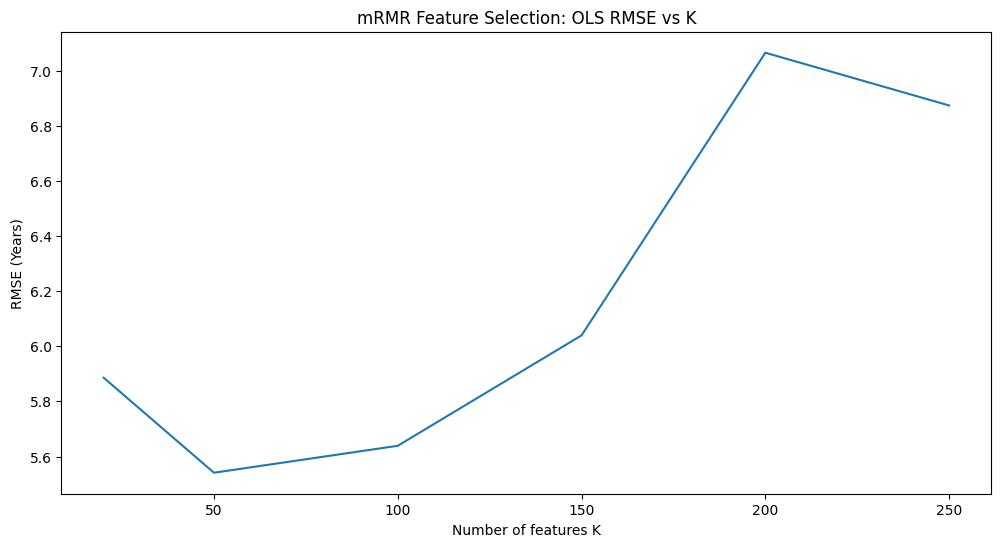

In [14]:
#Minimum Redundancy Maximum Relevance - MRMR
#To implement this algorithm I will assume (given the results from the respective RMSE data for the OLS models) that a large part of the varaiance in my data
#is explained by a linear relationship (to avoid also the mutual information which may be more computationally demanding).
#The first step is to select an optimum K value (number of selected features). For this purpose, I am going to perform an elbow analysis for defferent K vales and
# train an OLS model 

import os
import sys
from feature_engine.selection import MRMR

#Check for K = 20, 50, 100, 150, 200, 250
k_values = [20, 50, 100, 150, 200, 250]

k_RMSE = {}

for k in k_values:
    #Initialize the MRMR
    selector_mrmr = MRMR(method='FCD', regression=True, max_features=k)

    #Fit the mrmr selector to the data
    selector_mrmr.fit(X_train_cpg, y_train)

    selected_features = [f for f in X_train_cpg.columns if f not in selector_mrmr.features_to_drop_]

    #Filter the Data from training set
    X_train = X_train_cpg[selected_features]
    #Train an OLS model on selected features given k (proxy model)
    OLS_model = LinearRegression().fit(X_train, y_train)
    
    #Filter the Data from validation set
    X_val = X_val_cpg[selected_features]
    #Get predictions using the validation set
    y_pred = OLS_model.predict(X_val)

    RMSE = np.sqrt(mean_squared_error(y_val, y_pred))
    k_RMSE[k] = RMSE

results_k = pd.DataFrame(list(k_RMSE.items()), columns=['K', 'RMSE'])

print(results_k)

#RMSE Boxplot for the OLS RMSE for each k value
plt.figure(figsize=(12,6))
plt.plot(results_k['K'], results_k['RMSE'])
plt.title('mRMR Feature Selection: OLS RMSE vs K')
plt.xlabel('Number of features K')
plt.ylabel('RMSE (Years)')
plt.savefig('../figures/Task3_Figures/RMSE_OLS_vs_K.png', dpi=300, bbox_inches='tight')
plt.show()

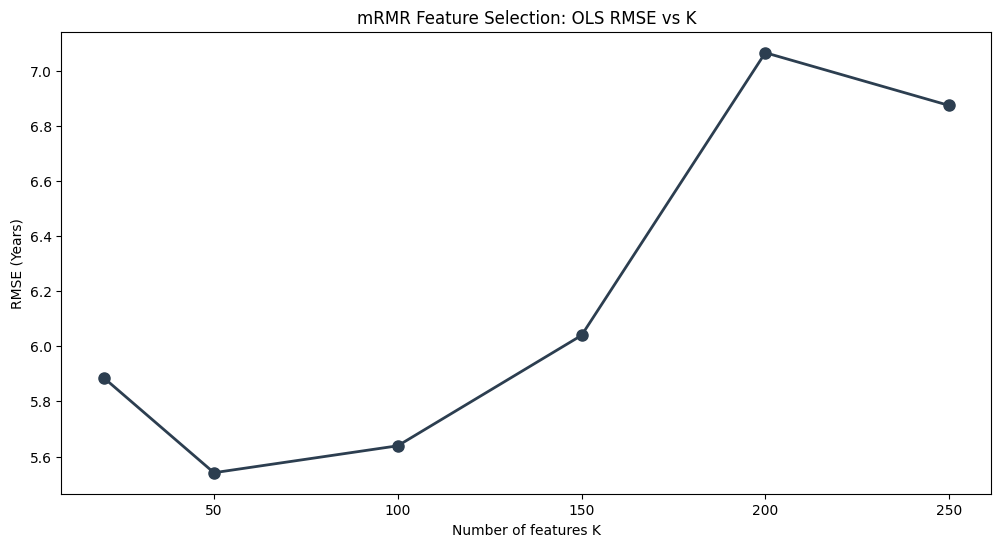

In [15]:
#RMSE Boxplot for the OLS RMSE for each k value
plt.figure(figsize=(12,6))
plt.plot(results_k['K'], results_k['RMSE'], 
         marker='o', linestyle='-', color='#2c3e50', 
         linewidth=2, markersize=8, label='Validation RMSE')
plt.title('mRMR Feature Selection: OLS RMSE vs K')
plt.xlabel('Number of features K')
plt.ylabel('RMSE (Years)')
plt.savefig('../figures/Task3_Figures/RMSE_OLS_vs_K.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
#Run the mRMR again with the selected number of features k - k=50
#Initialize the MRMR
selector_mrmr = MRMR(method='FCD', regression=True, max_features=50)

#Fit the mrmr selector to the data
selector_mrmr.fit(X_train_cpg, y_train)

selected_mrmr_features = [f for f in X_train_cpg.columns if f not in selector_mrmr.features_to_drop_]


In [17]:
# Find the feature names and their relevance scores
relevance_series = pd.Series(selector_mrmr.relevance_, index=selector_mrmr.variables_)

# Get the scores for the selected features and sort them to find top10
top_10_mrmr = relevance_series.loc[selected_mrmr_features].sort_values(ascending=False).head(10).reset_index()

top_10_mrmr.columns = ['CpG_Site', 'Relevance_Score']
top_10_mrmr.insert(0, 'Rank', range(1, 11))

#Save the table to csv format
top_10_mrmr.to_csv('../data/selected_features/top_10_mrmr.csv', index=False)
print(top_10_mrmr)


   Rank    CpG_Site  Relevance_Score
0     1  cg16867657       948.510657
1     2  cg06639320       492.865401
2     3  cg22454769       485.927793
3     4  cg24724428       443.282743
4     5  cg10501210       436.226014
5     6  cg21572722       424.452807
6     7  cg24079702       382.690731
7     8  cg06784991       320.740877
8     9  cg07553761       316.333385
9    10  cg01974375       309.022540


In [18]:
#Save the data for stability selection and mRMR
import json

#Create Directory
os.makedirs('../data/selected_features', exist_ok=True)

#Extract the names of the CpG features form the stability selection that passed the threshold
stable_features = stable_feature_freq.index.tolist()

#Create a dictionary with the selected features from the 2 methods
feature_sets = {
    "stable_features" : list(stable_features),
    "mrmr_features" : list(selected_mrmr_features)
}

#Save the dictionary
with open('../data/selected_features/selected_features.json', 'w') as f:
    json.dump(feature_sets, f)

print("Feature lists saved")


Feature lists saved


In [5]:
#Visualizationn of the overlap between the selected features from stability selection and the mRMR method
#Venn Diagram

#Load the data for the selected features
import json
import os 

file_path = '../data/selected_features/selected_features.json'

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        loaded_data = json.load(f)
    
    # Extract the lists with the features
    stable_features = loaded_data["stable_features"]
    selected_mrmr_features = loaded_data["mrmr_features"]
    
    print(f"Successfully loaded selected features lists")
    
else:
    print("Error: JSON file not found. Check your directory path!")

Successfully loaded selected features lists


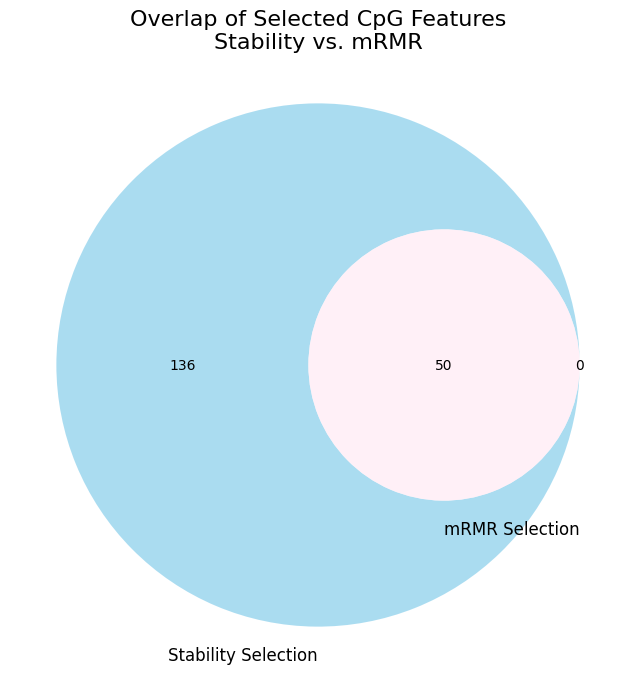

Number of common features: 50


In [8]:
from matplotlib_venn import venn2
#Ensure the folder exists
os.makedirs('../figures/Task3_Figures', exist_ok=True)

set_stable = set(stable_features)
set_mrmr = set(selected_mrmr_features)

#Generate the Venn plot
plt.figure(figsize=(10, 8))
venn = venn2(
    [set_stable, set_mrmr], 
    set_labels=('Stability Selection', 'mRMR Selection'),
    set_colors=('skyblue', 'salmon'),
    alpha=0.7
)
plt.title("Overlap of Selected CpG Features\nStability vs. mRMR", fontsize=16)
plt.savefig('../figures/Task3_Figures/Feature_Selection_Overlap_Venn.png', dpi=300, bbox_inches='tight')
plt.show()

#Calculate the intersection
common_features = set_stable.intersection(set_mrmr)
print(f"Number of common features: {len(common_features)}")

In [6]:
#Next goal is to compare the feature sets generated from the two methods for feature selection.
#For the validation I need a proxy model without complex hyperparameters, so I chose the OLS again. Any difference in the model performance is due to the quality of the features selected.

from src.functions import bootstrap_apply

#OLS initiation for the feature set from stability selection
OLS_stable = LinearRegression().fit(X_train_cpg[stable_features], y_train)
#OLS predictions for stable_features
OLS_stable_pred = OLS_stable.predict(X_val_cpg[stable_features])
#Apply bootstrap
bootstrap_stable = bootstrap_apply(OLS_stable_pred, y_val)

In [7]:
#OLS initiation for the feature set from nRMR
OLS_mrmr = LinearRegression().fit(X_train_cpg[selected_mrmr_features], y_train)
#OLS predictions on validation set 
OLS_mrmr_pred = OLS_mrmr.predict(X_val_cpg[selected_mrmr_features])
#Apply bootstrap
bootstrap_mrmr = bootstrap_apply(OLS_mrmr_pred, y_val)

In [8]:
#Compare the results from the validation of the OLS on the two different feature sets

comparison_data = {
    'Metric': [
        'Number of Features', 
        'Validation RMSE', 
        'RMSE 95% CI', 
        'Validation R2', 
        'R2 95% CI'
    ],
    'Stability Selection': [
        len(stable_features),
        f"{bootstrap_stable['RMSE'].mean():.2f}",
        f"({bootstrap_stable['RMSE'].quantile(0.025):.2f}, {bootstrap_stable['RMSE'].quantile(0.975):.2f})",
        f"{bootstrap_stable['R2'].mean():.3f}",
        f"({bootstrap_stable['R2'].quantile(0.025):.2f}, {bootstrap_stable['R2'].quantile(0.975):.2f})"
    ],
    'mRMR (K=50)': [
        len(selected_mrmr_features),
        f"{bootstrap_mrmr['RMSE'].mean():.3f}",
        f"({bootstrap_mrmr['RMSE'].quantile(0.025):.2f}, {bootstrap_mrmr['RMSE'].quantile(0.975):.2f})",
        f"{bootstrap_mrmr['R2'].mean():.3f}",
        f"({bootstrap_mrmr['R2'].quantile(0.025):.2f}, {bootstrap_mrmr['R2'].quantile(0.975):.2f})"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('../data/Task3_Final_Comparison_Table.csv', index=False)
print(comparison_df)

               Metric Stability Selection   mRMR (K=50)
0  Number of Features                 186            50
1     Validation RMSE                6.58         5.519
2         RMSE 95% CI        (5.54, 7.74)  (4.63, 6.47)
3       Validation R2               0.758         0.830
4           R2 95% CI        (0.66, 0.84)  (0.75, 0.89)


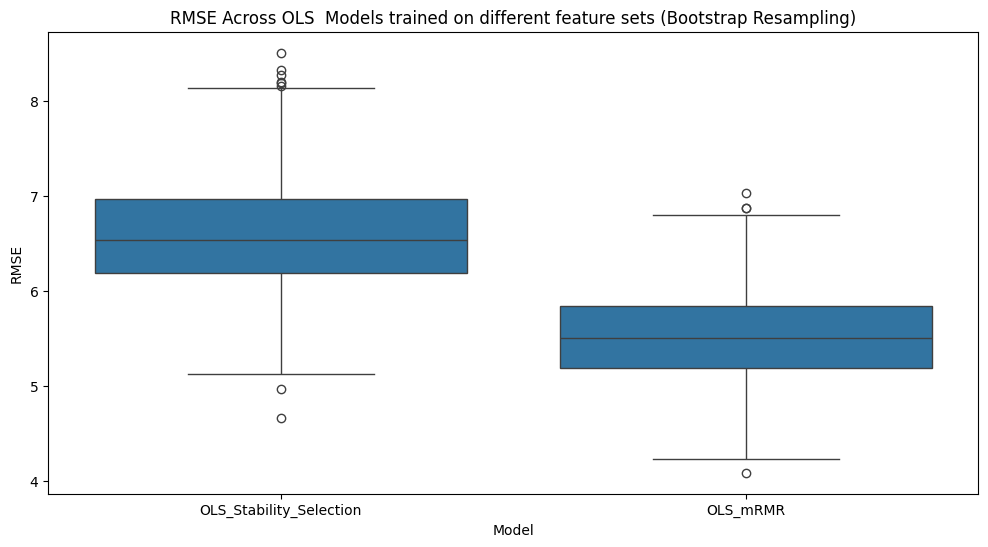

In [9]:
#Compare the 2 OLS models on the different feature sets (RMSE)
os.makedirs('../figures/Task3_Figures', exist_ok=True)

OLS_features_results = pd.concat([
    bootstrap_stable.assign(Model='OLS_Stability_Selection'),
    bootstrap_mrmr.assign(Model='OLS_mRMR')])

#RMSE Boxplot for the OLS models 
plt.figure(figsize=(12,6))
sns.boxplot(data=OLS_features_results, x='Model', y='RMSE')
plt.title('RMSE Across OLS  Models trained on different feature sets (Bootstrap Resampling)')
plt.savefig('../figures/Task3_Figures/RMSE_OLS_feature_sets.png', dpi=300, bbox_inches='tight')
plt.show()

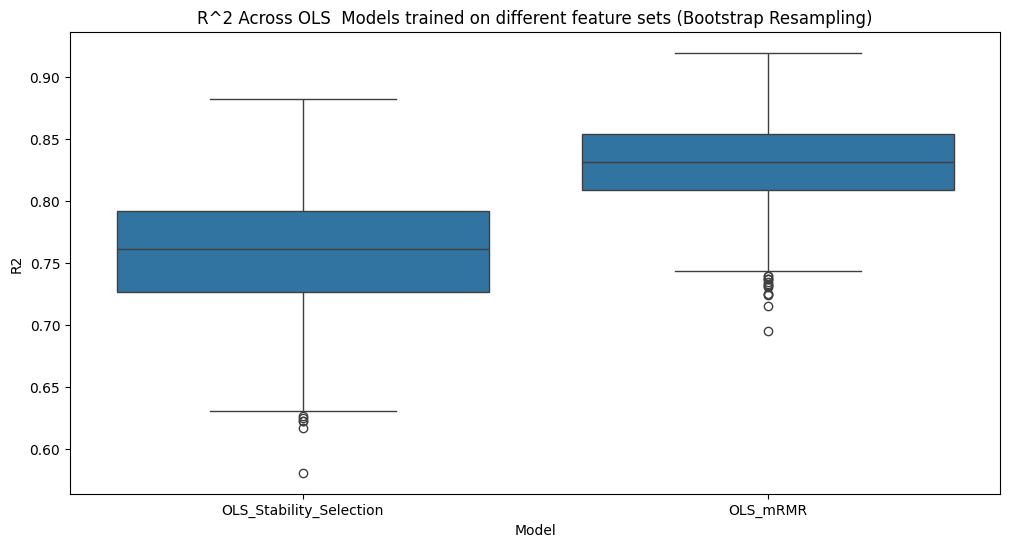

In [10]:
#R2 Boxplot for the OLS models 
plt.figure(figsize=(12,6))
sns.boxplot(data=OLS_features_results, x='Model', y='R2')
plt.title('R^2 Across OLS  Models trained on different feature sets (Bootstrap Resampling)')
plt.savefig('../figures/Task3_Figures/R2_OLS_feature_sets.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
#Save OLS models for the 2 different feature sets
import joblib

os.makedirs('../models/OLS_feature_sets', exist_ok=True)

joblib.dump(OLS_stable, '../models/OLS_feature_sets/ols_stability_selection_set.joblib' )
joblib.dump(OLS_mrmr, '../models/OLS_feature_sets/ols_mrmr_set.joblib' )


['../models/OLS_feature_sets/ols_mrmr_set.joblib']